In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

In [2]:
load_dotenv(override=True)

True

In [3]:
if os.environ.get("GOOGLE_API_KEY") is None:
    raise ValueError("GOOGLE_API_KEY is not set in the environment variables.")
else:
    llm = ChatGoogleGenerativeAI(
        model="gemini-3.5-flash-lite",
        api_key=os.environ.get("GOOGLE_API_KEY")
    )

In [4]:
from langchain_core.prompts import ChatPromptTemplate
my_prompt=ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant that translates English to Telugu."),
    ("human", "Here is the text to translate: {text}"),
])

In [5]:
## chain with prompts
chain = my_prompt | llm

In [7]:
chain.invoke({"text": "Hello, how are you?"}).text

'నమస్కారం, మీరు ఎలా ఉన్నారు?'

## **Tools** - **DuckDuckGo Search Tool**

In [28]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain.tools import tool
from langchain_core.messages import HumanMessage, ToolMessage

@tool
def search_duckduckgo(query: str) -> str:

    """This tool searches the latest news on DuckDuckGo for the given query and returns the results."""
    duck_search = DuckDuckGoSearchRun()
    return duck_search.invoke(query)

## Arxiv Query Tool

In [12]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

@tool
def arxiv_tool(query: str) -> str:

    """"This tool allows you to query the arXiv database for research papers."""
    arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())
    return arxiv_query.invoke(query)

## Wikipedia Tool

In [13]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def wiki_tool(query: str):

    """This tool allows you to search Wikipedia for information on a given topic."""
    wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_query.invoke(query)

## Custom Tool

In [14]:
@tool("add", description="Performs addition of two integers.")
def add(a: int, b: int) -> int:
    """Add two integers."""
    return a + b

In [38]:
## tool bind
tools=[search_duckduckgo, arxiv_tool, wiki_tool, add]
llm_with_tools = llm.bind_tools(tools)

response=llm_with_tools.invoke("latest news on AI") ## bind_tools only give tools to be called, but not the output. To get the output, we need to call the tool_calls attribute of the response object.


In [22]:
response.tool_calls[0]

{'name': 'search_duckduckgo',
 'args': {'query': 'latest news on AI artificial intelligence 2026'},
 'id': 'call_2097677',
 'type': 'tool_call'}

In [27]:
tool_call = response.tool_calls[0]
tool_name = tool_call["name"]
if tool_name == "search_duckduckgo":
    result = search_duckduckgo.invoke(
    tool_call["args"]
)
elif tool_name == "arxiv_tool":
    result = arxiv_tool.invoke(
    tool_call["args"]
)

elif tool_name == "wiki_tool":
    result = wiki_tool.invoke(
    tool_call["args"]
)
elif tool_name == "add":
    result = add.invoke(
    tool_call["args"]
)

print(f"Tool: {tool_name}\nResult: {result}")


Tool: search_duckduckgo
Result: Aug 3, 2026 · Artificial Intelligence News. Explore the latest news and insights surrounding AI with expert articles brought to you by AI News. 3 days ago · Daily AI news, model releases, and deep analysis for 2026. Track every announcement from OpenAI, Anthropic, Google, Meta, xAI, and the open-source ecosystem in one place. Mar 28, 2026 · Get the latest artificial intelligence news, breakthroughs, and analysis. AI Weekly covers model releases, startup funding, tools, and trends daily. Aug 6, 2026 · Artificial Intelligence News. Everything on AI including futuristic robots with artificial intelligence, computer models of human intelligence and more. Dec 15, 2025 · This article organizes 30 AI breakthroughs that redefined 2026 —from GPT-5.2 and DeepSeek to autonomous agents, robotics, and next-generation generative systems—based on real deployments and research announcements that actively changed the direction of AI.


## creating the graph to solve the problem(tool-> llm -> tool -> llm )

In [36]:
## create a schema for the graph
from typing import TypedDict, List 

class graph_schema(TypedDict):
    messages: List

In [37]:
## create llm node
def llm_node(state: graph_schema) -> graph_schema:
    
    messages = state['messages']

    # Prompt template for the LLM, including system instructions and the human input
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant that can use tools to answer questions."),
            ("human", "{input}")
        ]
    )

    chain = prompt | llm_with_tools 

    response = chain.invoke({"input": messages})

    # Update the state with the new message
    state['messages'] = messages + [response]

    return state

In [39]:
# from langgraph.prebuilt import ToolNode
def tool_node(state: graph_schema) -> graph_schema:

    messages = state['messages']

    tools_by_name = {tool.name: tool for tool in tools}

    tool_results = []

    for tool_call in messages[-1].tool_calls:

        tool = tools_by_name[tool_call["name"]]

        observation = tool.invoke(tool_call["args"])

        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    # Update the state with the tool results
    state['messages'] = messages + tool_results

    return state

In [41]:
## create Conditional Edge Function
def if_tool_call(state: graph_schema) -> str:

    last_message = state['messages'][-1]

    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

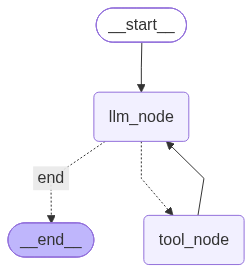

In [42]:
## create a graph
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

# Add nodes to the graph
graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

# Add edges between nodes
graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call,{"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)


react_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(react_graph.get_graph().draw_mermaid_png())

In [43]:
## graph Invokation
react_graph.invoke({"messages": [HumanMessage(content="What is the latest news on AI?")]})

{'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'search_duckduckgo', 'arguments': '{"query": "latest AI news 2026"}'}, '__gemini_function_call_thought_signatures__': {'call_2729243': 'El4KXAERTTIPSsDcSYwo+ZZV8lAqo8n3NrvM9ycY18IRYOr2+/V5SVCG5E/NRupIfquwSlghpv6bDXqRKkkC3TaYV7Kkg3UsopJbbosR4LVA9jKUvOf0HcO0n5rW/DKS'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a00a80-46d0-7a02-a2cf-84aabdf13e73-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'latest AI news 2026'}, 'id': 'call_2729243', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 251, 'output_tokens': 25, 'total_tokens': 276, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='16 hours ago - July 3, 2026 · categoryAlibaba, Tencent ba